
RESULTS
ROC-AUC: 0.8333
Average Precision: 0.1512
Best Threshold: 0.8170
Precision: 0.2358
Recall: 0.2143
F1: 0.2246

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.99      0.99      0.99   1085230
           1       0.24      0.21      0.22     17351

    accuracy                           0.98   1102581
   macro avg       0.61      0.60      0.61   1102581
weighted avg       0.98      0.98      0.98   1102581


CONFUSION MATRIX
[[1073178   12052]
 [  13632    3719]]

TOP 30 FEATURES
                        feature  importance
           cat__carrier_code_DL    0.053653
     num__HourlyPrecipitation_x    0.034068
     num__HourlyPrecipitation_y    0.024373
           cat__carrier_code_AA    0.018516
   cat__destination_airport_EWR    0.014178
        cat__origin_airport_EWR    0.013131
   cat__destination_airport_LGA    0.012427
        cat__origin_airport_JFK    0.012348
        num__HourlyVisibility_y    0.012045
        num__Hourl

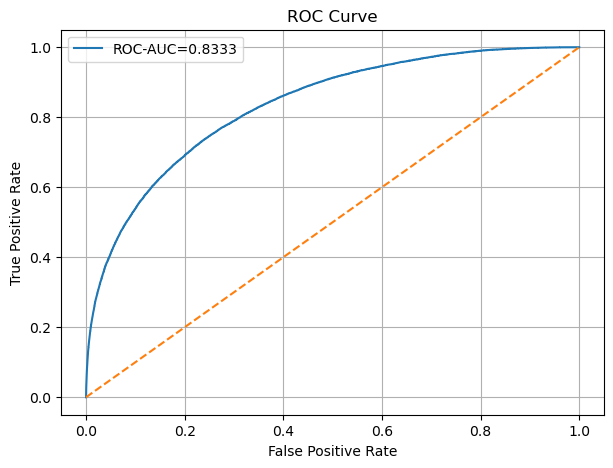

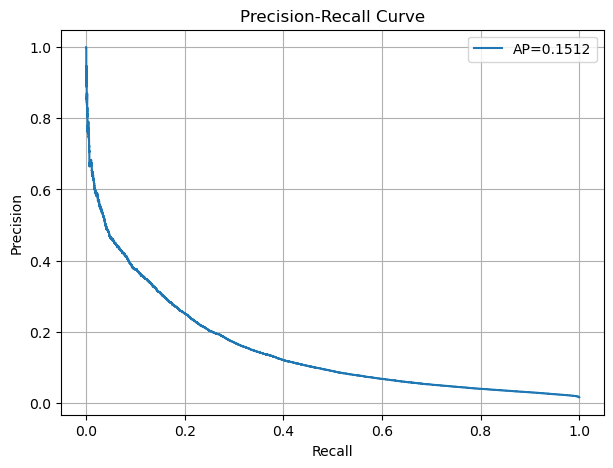

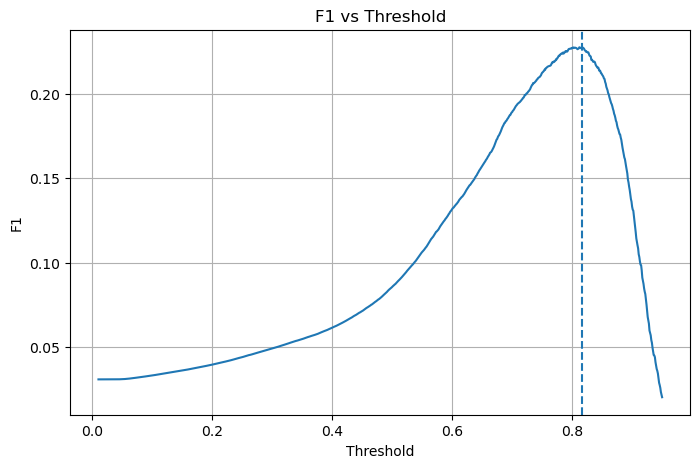

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    roc_auc_score,average_precision_score,precision_score,
    recall_score,f1_score,classification_report,confusion_matrix,
    roc_curve,precision_recall_curve
)
from xgboost import XGBClassifier

path=r"C:\Users\S.Lefakis\Documents\Project3\Data\merged_flight_weather.csv"
df=pd.read_csv(path)

df["Cancelled"]=(df["cancelled_code"]!="N").astype(int)
df=df.drop(columns="cancelled_code")

df["date"]=pd.to_datetime(df["date"],errors="coerce")
df["scheduled_departure_dt"]=pd.to_datetime(df["scheduled_departure_dt"],errors="coerce")
df=df.dropna(subset=["date","scheduled_departure_dt"])

df["departure_hour"]=df["scheduled_departure_dt"].dt.hour
df["route"]=df["origin_airport"].astype(str)+"_"+df["destination_airport"].astype(str)

cat=[
    "carrier_code",
    "flight_number",
    "origin_airport",
    "destination_airport",
    "route"
]

num=[
    "scheduled_elapsed_time",
    "year",
    "month",
    "weekday",
    "departure_hour",
    "HourlyDryBulbTemperature_x",
    "HourlyPrecipitation_x",
    "HourlyStationPressure_x",
    "HourlyVisibility_x",
    "HourlyWindSpeed_x",
    "HourlyDryBulbTemperature_y",
    "HourlyPrecipitation_y",
    "HourlyStationPressure_y",
    "HourlyVisibility_y",
    "HourlyWindSpeed_y"
]

X=df[cat+num]
y=df["Cancelled"]

X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

scale_pos_weight=(y_train==0).sum()/(y_train==1).sum()

preprocessor=ColumnTransformer([
    ("num",SimpleImputer(strategy="median"),num),
    ("cat",Pipeline([
        ("imputer",SimpleImputer(strategy="most_frequent")),
        ("encoder",OneHotEncoder(handle_unknown="ignore",sparse_output=True))
    ]),cat)
],sparse_threshold=1.0)

xgb=XGBClassifier(
    objective="binary:logistic",
    n_estimators=200,
    max_depth=6,
    learning_rate=0.03,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.7,
    gamma=0.1,
    reg_alpha=0,
    reg_lambda=1,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

model=Pipeline([
    ("preprocessor",preprocessor),
    ("model",xgb)
])

X_tr,X_val,y_tr,y_val=train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    stratify=y_train,
    random_state=42
)

model.fit(X_tr,y_tr)

val_prob=model.predict_proba(X_val)[:,1]

thresholds=np.arange(0.01,0.951,0.001)
f1s=[f1_score(y_val,val_prob>=t,zero_division=0) for t in thresholds]
best_threshold=thresholds[np.argmax(f1s)]

test_prob=model.predict_proba(X_test)[:,1]
test_pred=(test_prob>=best_threshold).astype(int)

roc=roc_auc_score(y_test,test_prob)
ap=average_precision_score(y_test,test_prob)
precision=precision_score(y_test,test_pred,zero_division=0)
recall=recall_score(y_test,test_pred,zero_division=0)
f1=f1_score(y_test,test_pred,zero_division=0)

print("\nRESULTS")
print(f"ROC-AUC: {roc:.4f}")
print(f"Average Precision: {ap:.4f}")
print(f"Best Threshold: {best_threshold:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1: {f1:.4f}")

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test,test_pred,zero_division=0))

print("\nCONFUSION MATRIX")
print(confusion_matrix(y_test,test_pred))

features=model.named_steps["preprocessor"].get_feature_names_out()
importance=model.named_steps["model"].feature_importances_

fi=pd.DataFrame({
    "feature":features,
    "importance":importance
}).sort_values("importance",ascending=False)

print("\nTOP 30 FEATURES")
print(fi.head(30).to_string(index=False))

fpr,tpr,_=roc_curve(y_test,test_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr,tpr,label=f"ROC-AUC={roc:.4f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

pr,rc,_=precision_recall_curve(y_test,test_prob)

plt.figure(figsize=(7,5))
plt.plot(rc,pr,label=f"AP={ap:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(thresholds,f1s)
plt.axvline(best_threshold,linestyle="--")
plt.xlabel("Threshold")
plt.ylabel("F1")
plt.title("F1 vs Threshold")
plt.grid()
plt.show()